LOADING FRUIT AND VEGETABLE DATASET FROM KAGGLE USING KAGGLE API

In [1]:
from google.colab import files
files.upload()  # LOADING THE KAGGLE.JSON FILE FOR AUTHENTICATION

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sona143","key":"a47807b9a24dc22be2d1453e037565d7"}'}

*** setting up Kaggle API access in Google Colab. ***

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

DOWNLOADING THE DATASET THROUGH KAGGLE API

In [3]:
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition
#!unzip kritikseth/fruit-and-vegetable-image-recognition.zip -d dataset/
!unzip fruit-and-vegetable-image-recognition.zip -d dataset/

Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
 99% 1.96G/1.98G [00:17<00:00, 127MB/s] 
100% 1.98G/1.98G [00:18<00:00, 118MB/s]
Archive:  fruit-and-vegetable-image-recognition.zip
  inflating: dataset/test/apple/Image_1.jpg  
  inflating: dataset/test/apple/Image_10.jpg  
  inflating: dataset/test/apple/Image_2.jpg  
  inflating: dataset/test/apple/Image_3.jpg  
  inflating: dataset/test/apple/Image_4.jpg  
  inflating: dataset/test/apple/Image_5.jpg  
  inflating: dataset/test/apple/Image_6.JPG  
  inflating: dataset/test/apple/Image_7.jpg  
  inflating: dataset/test/apple/Image_8.jpg  
  inflating: dataset/test/apple/Image_9.jpg  
  inflating: dataset/test/banana/Image_1.jpg  
  inflating: dataset/test/banana/Image_10.jpg  
  inflating: dataset/test/banana/Image_2.jpg  
  inflating: dataset/test/banana/Image_3.jpg  
  inflating: dataset/test/banana/Image_4.jpg  
  inflating: dataset/test/banana/Image_5.jpg  
  inflati

# IMPORT NECCESSORY LIBRARIES

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random


DEFINE FRUIT AND VEGETABLE LABELS


In [5]:
fruit_labels = ['banana', 'apple', 'pear', 'grapes', 'orange', 'kiwi', 'watermelon', 'pomegranate', 'pineapple', 'mango']
vegetable_labels = ['cucumber', 'carrot', 'capsicum', 'onion', 'potato', 'lemon', 'tomato', 'raddish', 'beetroot', 'cabbage',
                    'lettuce', 'spinach', 'soy beans', 'cauliflower', 'bell pepper', 'chilli pepper', 'turnip', 'corn',
                    'sweetcorn', 'sweetpotato', 'paprika', 'jalepeno', 'ginger', 'garlic', 'peas', 'eggplant']


SETTING IMAGE SIZE ,CONNECTION TO BASE DIRECTORY AND INSIDE TRAIN ,TEST ,VALIDATION FOLDERS

In [6]:
IMG_SIZE = 100
base_dir = "/content/dataset"
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

# Create ImageDataGenerators with class_mode='categorical'

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical' # Get one-hot encoded labels for each individual class
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32,
    class_mode='categorical'
)


Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.


# Get the class indices and create the binary label mapping

In [8]:
class_indices = train_generator.class_indices
print("Generator's Class Indices:", class_indices)

Generator's Class Indices: {'apple': 0, 'banana': 1, 'beetroot': 2, 'bell pepper': 3, 'cabbage': 4, 'capsicum': 5, 'carrot': 6, 'cauliflower': 7, 'chilli pepper': 8, 'corn': 9, 'cucumber': 10, 'eggplant': 11, 'garlic': 12, 'ginger': 13, 'grapes': 14, 'jalepeno': 15, 'kiwi': 16, 'lemon': 17, 'lettuce': 18, 'mango': 19, 'onion': 20, 'orange': 21, 'paprika': 22, 'pear': 23, 'peas': 24, 'pineapple': 25, 'pomegranate': 26, 'potato': 27, 'raddish': 28, 'soy beans': 29, 'spinach': 30, 'sweetcorn': 31, 'sweetpotato': 32, 'tomato': 33, 'turnip': 34, 'watermelon': 35}


In [9]:
# Create a mapping from generator's class index to binary label (0 for fruit, 1 for veg)
binary_label_mapping = {}
for class_name, index in class_indices.items():
    # Convert class_name to lowercase for case-insensitive matching if needed
    # class_name_lower = class_name.lower()
    if class_name in fruit_labels: # Use your fruit_labels list
        binary_label_mapping[index] = 0 # Fruit
    elif class_name in vegetable_labels: # Use your vegetable_labels list
        binary_label_mapping[index] = 1 # Vegetable
    else:
        print(f"Warning: Class '{class_name}' not found in fruit_labels or vegetable_labels. Assigning -1.")
        binary_label_mapping[index] = -1 # Indicator for unknown class

print("Binary Label Mapping:", binary_label_mapping)


Binary Label Mapping: {0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 0, 15: 1, 16: 0, 17: 1, 18: 1, 19: 0, 20: 1, 21: 0, 22: 1, 23: 0, 24: 1, 25: 0, 26: 0, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 0}


# Create a custom generator function to yield images and binary labels

In [10]:
def binary_generator(generator, binary_label_mapping):
    while True:
        images, one_hot_labels = next(generator)
        # Convert one-hot encoded labels to integer indices
        class_indices_batch = np.argmax(one_hot_labels, axis=1)
        # Map integer indices to binary labels
        binary_labels = np.array([binary_label_mapping[index] for index in class_indices_batch])
        yield images, binary_labels

# Create the binary generators for training, validation, and testing
train_binary_generator = binary_generator(train_generator, binary_label_mapping)
val_binary_generator = binary_generator(val_generator, binary_label_mapping)
test_binary_generator = binary_generator(test_generator, binary_label_mapping)


 Build CNN Model ( output layer is for binary classification,CLASSIFY INTO FRUIT OR VEGETABLE)


 --TWO CONVOLUTION +ACTIVATION (RELU) LAYERS , EACH FOLLOWED BY A POOLING LAYER (MAX POOLING IS USED)

 --FLATTENING

 ---OUTPUT LAYER

In [11]:

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Single output unit for binary classification
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# COMPILE THE MODEL

In [12]:

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model using the custom binary generator

In [13]:

# Calculate steps per epoch and validation steps based on the original generators
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = val_generator.samples // val_generator.batch_size

history = model.fit(
    train_binary_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_binary_generator,
    validation_steps=validation_steps,
    epochs=10
)

Epoch 1/10
13/97 ━━━━━━━━━━━━━━━━━━━━ 1:40 1s/step - accuracy: 0.6611 - loss: 1.1803

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


14/97 ━━━━━━━━━━━━━━━━━━━━ 1:41 1s/step - accuracy: 0.6617 - loss: 1.1605

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


23/97 ━━━━━━━━━━━━━━━━━━━━ 1:37 1s/step - accuracy: 0.6707 - loss: 1.0313

...

96/97 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9306 - loss: 0.1882

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9305 - loss: 0.1883

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1043: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


97/97 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.9304 - loss: 0.1883 - val_accuracy: 0.9467 - val_loss: 0.1556


# Evaluate and Plot Results

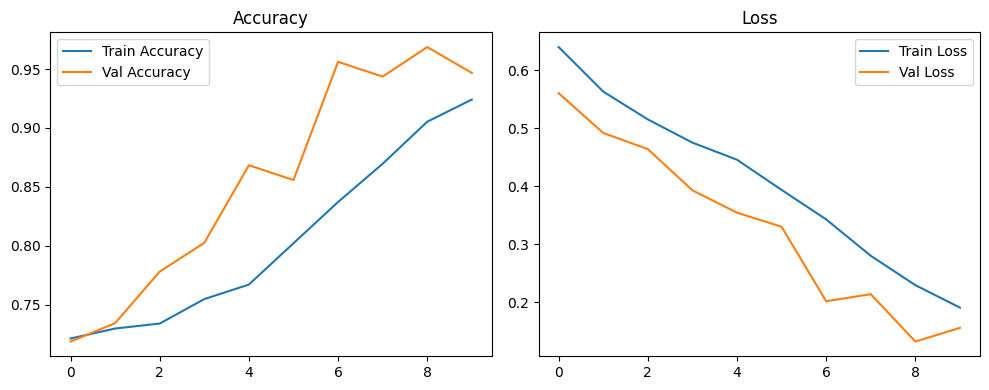

In [14]:


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.tight_layout()
plt.show()


#  Display Sample Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


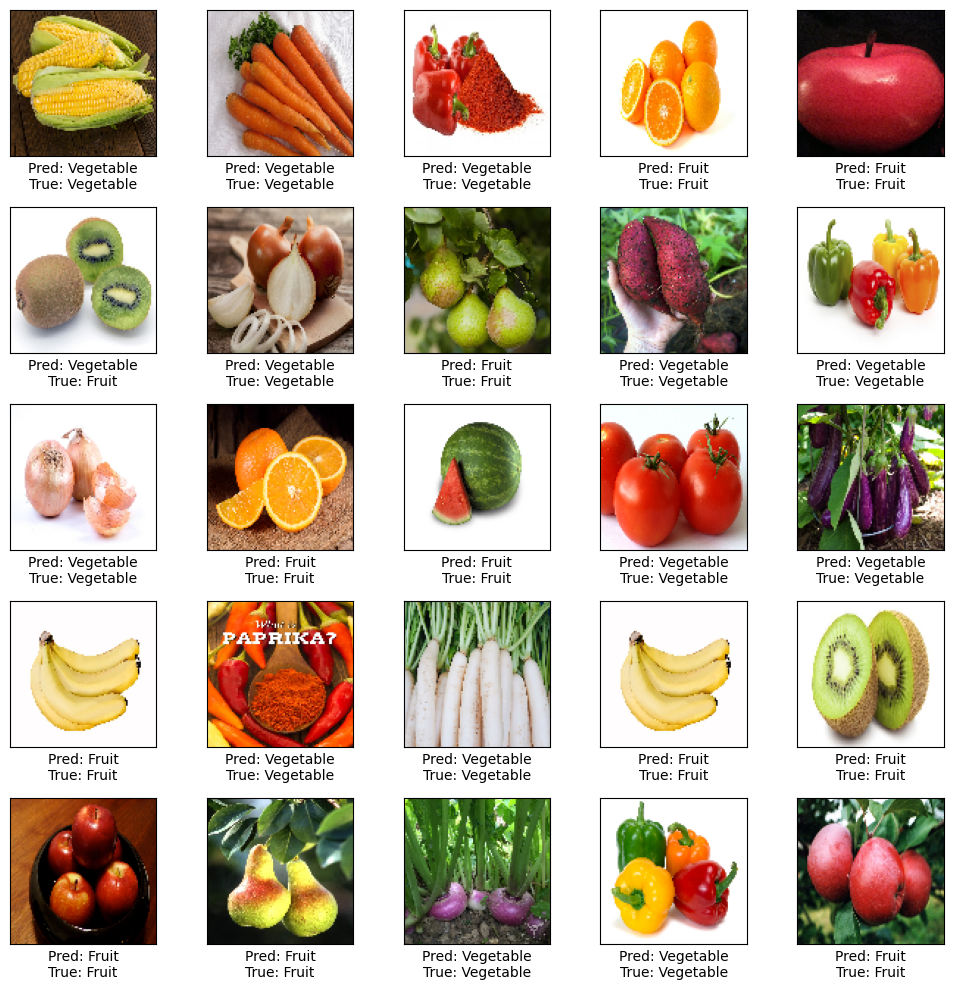

In [15]:

class_names = ['Fruit', 'Vegetable'] # Your binary class names

# Get a batch of images and binary labels from the test binary generator
test_images_sample, test_binary_labels_sample = next(test_binary_generator)

plt.figure(figsize=(10, 10))
for i in range(min(25, len(test_images_sample))): # Display up to 25 images
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images_sample[i])
    # Make prediction for the single image
    prediction = model.predict(np.expand_dims(test_images_sample[i], axis=0))[0][0]

    # Determine the predicted binary label
    predicted_label_index = 1 if prediction > 0.5 else 0
    predicted_label = class_names[predicted_label_index]

    # Get the true binary label
    true_label_index = test_binary_labels_sample[i]
    true_label = class_names[true_label_index]

    # Display the predicted and true labels
    plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}")

plt.tight_layout()
plt.show()



In [16]:


# STEP 11: Evaluate the model on the test dataset
print("\nEvaluating the model on the test dataset...")
test_loss, test_acc = model.evaluate(test_binary_generator, steps=test_generator.samples // test_generator.batch_size, verbose=1)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


Evaluating the model on the test dataset...
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9722 - loss: 0.1109
Test Accuracy: 0.9572
Test Loss: 0.1502
